- [ ] Does DNF/incident rate correlate with circuit type, team, or weather conditions? (chi-square: DNF vs. circuit type / team / rainfall)
- [ ] Are certain teams' cars statistically more fragile, or is it concentrated in specific drivers? (compare DNF rate by team vs. by driver)
- [ ] Does rain increase the *variance* of finishing positions across the field, not just average pace? (compare position variance in wet vs. dry races F-test / Levene's test)
- [ ] Do specific teams or drivers statistically outperform their own dry-weather baseline in wet races? (paired comparison, same driver/team, wet vs. dry)

In [1]:
import sys
sys.path.append("../")
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm


import sqlite3

conn = sqlite3.connect("../DATA INGESTION/f1.db")

- [X] Does DNF/incident rate correlate with circuit type, team, or weather conditions? (chi-square: DNF vs. circuit type / team / rainfall)

In [3]:
from data_prep import normalize_team_names

dnf_query = """
SELECT sr.session_key, sr.driver_number,sr.dnf,d.team_name, m.circuit_type, MAX(w.rainfall) AS race_had_rain
FROM silver_session_result sr
JOIN silver_sessions s ON sr.session_key = s.session_key 
    AND s.session_name = 'Race'
JOIN silver_meetings m ON s.meeting_key = m.meeting_key
JOIN silver_drivers d ON sr.session_key = d.session_key 
    AND sr.driver_number = d.driver_number
LEFT JOIN silver_weather w ON sr.session_key = w.session_key
WHERE sr.dns = 0
GROUP BY sr.session_key, sr.driver_number, sr.dnf, 
         d.team_name, m.circuit_type
"""
df_dnf = pd.read_sql(dnf_query, conn)
df_dnf = normalize_team_names(df_dnf)
df_dnf = df_dnf[df_dnf['team_name'] != 'Cadillac'].copy()

print(df_dnf.shape)
print(df_dnf['dnf'].value_counts())
print(df_dnf['circuit_type'].value_counts())
print(df_dnf['race_had_rain'].value_counts())

(1460, 6)
dnf
0    1280
1     180
Name: count, dtype: int64
circuit_type
Permanent             945
Temporary - Street    455
Temporary - Road       60
Name: count, dtype: int64
race_had_rain
0.0    1086
1.0     315
Name: count, dtype: int64


In [4]:
from scipy.stats import chi2_contingency

# Circuit type
table_circuit = pd.crosstab(df_dnf['circuit_type'], df_dnf['dnf'])
chi2, p, dof, expected = chi2_contingency(table_circuit)
print("CIRCUIT TYPE:")
print(table_circuit)
print(df_dnf.groupby('circuit_type')['dnf'].mean().round(3))
print(f"chi2={chi2:.3f}, p={p:.6f}, expected cells<5: {(expected<5).sum()}\n")

# Team
table_team = pd.crosstab(df_dnf['team_name'], df_dnf['dnf'])
chi2_t, p_t, dof_t, expected_t = chi2_contingency(table_team)
print("TEAM:")
print(table_team)
print(df_dnf.groupby('team_name')['dnf'].mean().round(3))
print(f"chi2={chi2_t:.3f}, p={p_t:.6f}, expected cells<5: {(expected_t<5).sum()}\n")

# Rainfall
table_rain = pd.crosstab(df_dnf['race_had_rain'], df_dnf['dnf'])
chi2_r, p_r, dof_r, expected_r = chi2_contingency(table_rain)
print("RAINFALL:")
print(table_rain)
print(df_dnf.groupby('race_had_rain')['dnf'].mean().round(3))
print(f"chi2={chi2_r:.3f}, p={p_r:.6f}, expected cells<5: {(expected_r<5).sum()}")

CIRCUIT TYPE:
dnf                   0    1
circuit_type                
Permanent           835  110
Temporary - Road     57    3
Temporary - Street  388   67
circuit_type
Permanent             0.116
Temporary - Road      0.050
Temporary - Street    0.147
Name: dnf, dtype: float64
chi2=5.814, p=0.054649, expected cells<5: 0

TEAM:
dnf                0   1
team_name               
Alpine           127  19
Aston Martin     119  26
Ferrari          134  12
Haas F1 Team     131  17
McLaren          137   8
Mercedes         133  15
RB Family        127  18
Red Bull Racing  133  15
Sauber Family    127  18
Williams         112  32
team_name
Alpine             0.130
Aston Martin       0.179
Ferrari            0.082
Haas F1 Team       0.115
McLaren            0.055
Mercedes           0.101
RB Family          0.124
Red Bull Racing    0.101
Sauber Family      0.124
Williams           0.222
Name: dnf, dtype: float64
chi2=27.236, p=0.001278, expected cells<5: 0

RAINFALL:
dnf              0    1
r

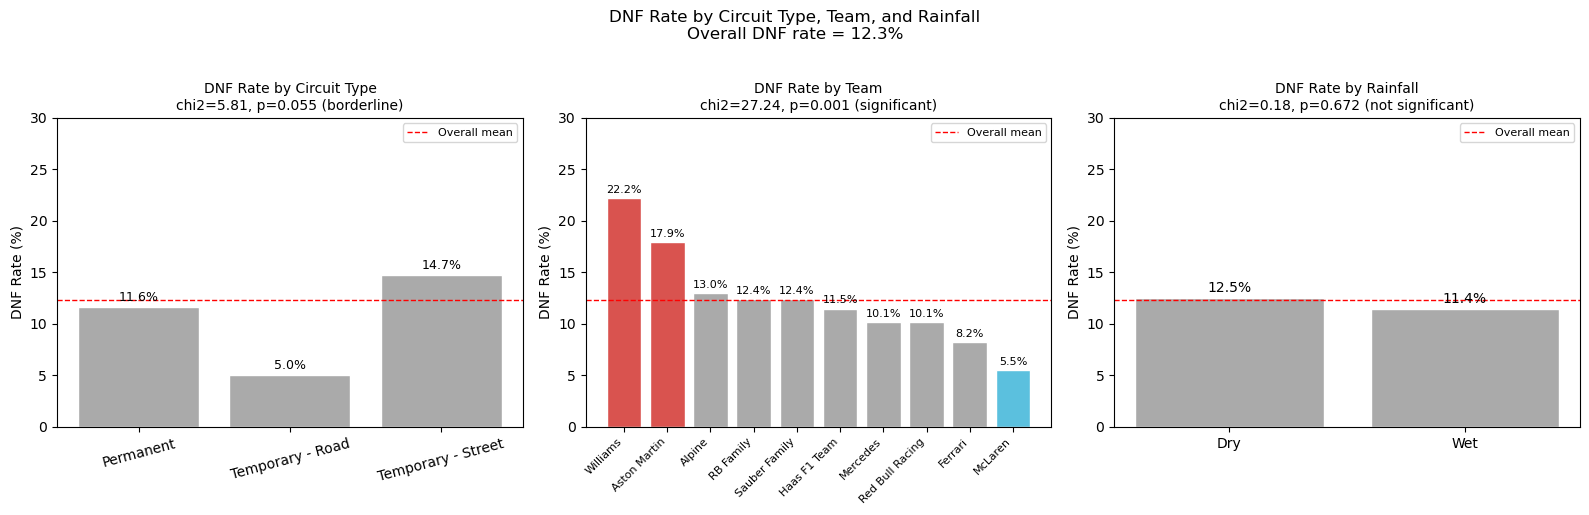

In [6]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Circuit type
circuit_rates = df_dnf.groupby('circuit_type')['dnf'].mean() * 100
bars = axes[0].bar(circuit_rates.index, circuit_rates.values, 
                   color='#aaaaaa', edgecolor='white')
axes[0].axhline(y=df_dnf['dnf'].mean()*100, color='red', linestyle='--', 
                linewidth=1, label='Overall mean')
axes[0].set_title('DNF Rate by Circuit Type\nchi2=5.81, p=0.055 (borderline)', fontsize=10)
axes[0].set_ylabel('DNF Rate (%)')
axes[0].set_ylim(0, 30)
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(fontsize=8)
for bar, val in zip(bars, circuit_rates.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

# 2. Team
team_rates = df_dnf.groupby('team_name')['dnf'].mean() * 100
team_rates = team_rates.sort_values(ascending=False)
bar_colors = ['#d9534f' if v > 15 else '#5bc0de' if v < 8 else '#aaaaaa' 
              for v in team_rates.values]
bars2 = axes[1].bar(range(len(team_rates)), team_rates.values, 
                     color=bar_colors, edgecolor='white')
axes[1].axhline(y=df_dnf['dnf'].mean()*100, color='red', linestyle='--', 
                linewidth=1, label='Overall mean')
axes[1].set_title('DNF Rate by Team\nchi2=27.24, p=0.001 (significant)', fontsize=10)
axes[1].set_ylabel('DNF Rate (%)')
axes[1].set_ylim(0, 30)
axes[1].set_xticks(range(len(team_rates)))
axes[1].set_xticklabels(team_rates.index, rotation=45, ha='right', fontsize=8)
axes[1].legend(fontsize=8)
for bar, val in zip(bars2, team_rates.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

# 3. Rainfall
rain_rates = df_dnf.groupby('race_had_rain')['dnf'].mean() * 100
rain_labels = ['Dry', 'Wet']
bars3 = axes[2].bar(rain_labels, rain_rates.values, 
                     color='#aaaaaa', edgecolor='white')
axes[2].axhline(y=df_dnf['dnf'].mean()*100, color='red', linestyle='--', 
                linewidth=1, label='Overall mean')
axes[2].set_title('DNF Rate by Rainfall\nchi2=0.18, p=0.672 (not significant)', 
                  fontsize=10)
axes[2].set_ylabel('DNF Rate (%)')
axes[2].set_ylim(0, 30)
axes[2].legend(fontsize=8)
for bar, val in zip(bars3, rain_rates.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

plt.suptitle('DNF Rate by Circuit Type, Team, and Rainfall\nOverall DNF rate = 12.3%', 
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

METHOD:
Population: all race starters (dns=0) across Race sessions 2023-2026, 
Cadillac excluded. n=1,460 driver-race rows, 180 DNFs (12.3% overall rate).

Three separate chi-square tests of independence:
  1. circuit_type x dnf (3 circuit categories x 2 outcomes)
  2. team_name x dnf (10 teams x 2 outcomes)
  3. race_had_rain x dnf (binary rainfall x 2 outcomes)

Rainfall defined as MAX(silver_weather.rainfall) per session -- binary flag 
for "did it rain at any point during this race." Captures wet-race exposure 
without requiring a threshold on duration or intensity.

RESULT 1 -- CIRCUIT TYPE: chi2=5.81, p=0.055, dof=2, expected cells<5: 0
BORDERLINE -- just above the standard significance threshold.

DNF rates:
  Street circuits:        14.7%  (highest)
  Permanent circuits:     11.6%  (middle)
  Temporary-Road:          5.0%  (lowest, but n=60 -- thin)

Direction is physically sensible (street circuits have walls instead of 
run-off areas, incidents more likely to end races rather than result in 
track excursions). But p=0.055 doesn't clear the standard threshold. 
Temporary-Road's low rate (5%) is unreliable given only 60 rows and 3 DNFs. 
Cannot conclude a statistically confirmed circuit-type effect, but the 
Street vs Permanent direction is worth noting as a plausible trend.

RESULT 2 -- TEAM: chi2=27.24, p=0.001, dof=9, expected cells<5: 0
SIGNIFICANT -- fully reliable, strong team effect confirmed.

DNF rates by team (sorted):
  Williams:        22.2%  -- highest, more than 1 in 5 starts ends in DNF
  Aston Martin:    17.9%
  Alpine:          13.0%
  RB Family:       12.4%
  Sauber Family:   12.4%
  Haas F1 Team:    11.5%
  Mercedes:        10.1%
  Red Bull Racing: 10.1%
  Ferrari:          8.2%
  McLaren:          5.5%  -- lowest, most reliable

Two clear reliability tiers visible in the bar chart (color-coded):
  HIGH DNF RATE (red bars, >15%): Williams, Aston Martin
  LOW DNF RATE (blue bars, <8%): McLaren, Ferrari
  MIDDLE CLUSTER (gray): remaining 6 teams, 10-13% range

Williams (22.2%) and McLaren (5.5%) represent the extremes -- a 4x 
difference in DNF rate between the most and least reliable teams. This 
is a statistically real, team-specific reliability effect, not random 
attrition.

RESULT 3 -- RAINFALL: chi2=0.18, p=0.672, dof=1, expected cells<5: 0
NOT SIGNIFICANT -- rain has essentially no association with DNF rate.

DNF rates: dry races 12.5%, wet races 11.4% -- virtually identical.
Counterintuitive but defensible: F1 has several mechanisms that offset 
the expected "rain = more incidents = more DNFs" story:
  - Race directors deploy Safety Cars and VSCs more aggressively in wet 
    conditions, reducing on-track incident severity
  - Teams and drivers adapt strategy conservatively in rain
  - Wet-race incidents often result in spins/recoveries rather than 
    terminal damage, since speeds are lower
  - Red flags (full race suspension) in extreme wet conditions can reset 
    the race, reducing accumulated attrition

OVERALL RANKING -- WHICH FACTOR MATTERS:
  1. TEAM: clearly significant (p=0.001). Some teams are genuinely more 
     fragile than others -- a real engineering/reliability effect.
  2. CIRCUIT TYPE: borderline (p=0.055). Plausible direction but not 
     statistically confirmed with this sample.
  3. RAINFALL: completely non-significant (p=0.672). Rain does not 
     increase DNF rate in this data.

CONVERGES WITH EARLIER FINDINGS:
The lapped-driver analysis showed Williams with the highest lapping rate 
(37.8%) and McLaren with one of the lowest (6.7%). The DNF analysis now 
adds a second dimension: Williams also has the highest DNF rate (22.2%) 
and McLaren the lowest (5.5%). Both measures -- lapping rate and DNF rate 
-- point at the same underlying story: Williams is consistently the most 
fragile team on pace AND reliability, while McLaren is the most robust.

METHODOLOGICAL NOTE:
Rainfall defined as "any rain during the session" rather than "majority 
wet" or "intensity-weighted." A stricter definition (e.g., >50% of 
samples showing rain) might yield a different result for "fully wet 
races" specifically. Left as a possible future refinement.

- [X] Are certain teams' cars statistically more fragile, or is it concentrated in specific drivers? (compare DNF rate by team vs. by driver)

In [14]:
driver_dnf_query = """
SELECT sr.session_key, sr.driver_number,
       sr.dnf, d.full_name, d.team_name
FROM silver_session_result sr
JOIN silver_sessions s ON sr.session_key = s.session_key 
    AND s.session_name = 'Race'
JOIN silver_drivers d ON sr.session_key = d.session_key 
    AND sr.driver_number = d.driver_number
WHERE sr.dns = 0
"""
df_driver_dnf = pd.read_sql(driver_dnf_query, conn)
df_driver_dnf = normalize_team_names(df_driver_dnf)
df_driver_dnf = df_driver_dnf[df_driver_dnf['team_name'] != 'Cadillac'].copy()

driver_rates = df_driver_dnf.groupby(['driver_number','full_name','team_name']).agg(
    starts=('dnf','count'),
    dnfs=('dnf','sum')
).reset_index()
driver_rates['dnf_rate'] = driver_rates['dnfs'] / driver_rates['starts']

# apply minimum starts threshold .
# with fewer than 15 starts, a driver's DNF rate is so noisy it's barely worth computing.
driver_rates = driver_rates[driver_rates['starts'] >= 20].copy()

print(driver_rates.shape)
print(driver_rates.sort_values('dnf_rate', ascending=False))

(31, 6)
    driver_number          full_name        team_name  starts  dnfs  dnf_rate
2               2     Logan SARGEANT         Williams      34     8  0.235294
20             23    Alexander ALBON         Williams      72    15  0.208333
37             55       Carlos SAINZ         Williams      29     6  0.206897
15             18       Lance STROLL     Aston Martin      71    14  0.197183
26             31       Esteban OCON           Alpine      43     8  0.186047
24             30        Liam LAWSON        RB Family      34     6  0.176471
12             12     Kimi ANTONELLI         Mercedes      30     5  0.166667
16             20    Kevin MAGNUSSEN     Haas F1 Team      42     7  0.166667
42             87     Oliver BEARMAN     Haas F1 Team      30     5  0.166667
13             14    Fernando ALONSO     Aston Martin      74    12  0.162162
11             11       Sergio PEREZ  Red Bull Racing      44     7  0.159091
23             27    Nico HULKENBERG    Sauber Family   

In [15]:
# Sainz specifically -- compare Ferrari vs Williams DNF rates
sainz = driver_rates[driver_rates['full_name'] == 'Carlos SAINZ']
print(sainz[['full_name','team_name','starts','dnfs','dnf_rate']])

       full_name team_name  starts  dnfs  dnf_rate
36  Carlos SAINZ   Ferrari      42     5  0.119048
37  Carlos SAINZ  Williams      29     6  0.206897


In [17]:
team_driver_summary = driver_rates.groupby('team_name').agg(
    n_drivers=('driver_number','count'),
    mean_dnf_rate=('dnf_rate','mean'),
    std_dnf_rate=('dnf_rate','std'),
    min_dnf_rate=('dnf_rate','min'),
    max_dnf_rate=('dnf_rate','max')
).reset_index()

team_driver_summary['rate_spread'] = (
    team_driver_summary['max_dnf_rate'] - team_driver_summary['min_dnf_rate']
)

print(team_driver_summary.sort_values('mean_dnf_rate', ascending=False).to_string())

         team_name  n_drivers  mean_dnf_rate  std_dnf_rate  min_dnf_rate  max_dnf_rate  rate_spread
9         Williams          3       0.216841      0.015997      0.206897      0.235294     0.028398
1     Aston Martin          2       0.179673      0.024764      0.162162      0.197183     0.035021
8    Sauber Family          4       0.127015      0.015579      0.113636      0.142857     0.029221
6        RB Family          4       0.122094      0.042059      0.083333      0.176471     0.093137
3     Haas F1 Team          4       0.114394      0.064775      0.033333      0.166667     0.133333
5         Mercedes          3       0.109814      0.050976      0.068182      0.166667     0.098485
0           Alpine          3       0.103111      0.094650      0.000000      0.186047     0.186047
7  Red Bull Racing          3       0.079798      0.069372      0.030303      0.159091     0.128788
2          Ferrari          3       0.078191      0.042997      0.033333      0.119048     0.085714


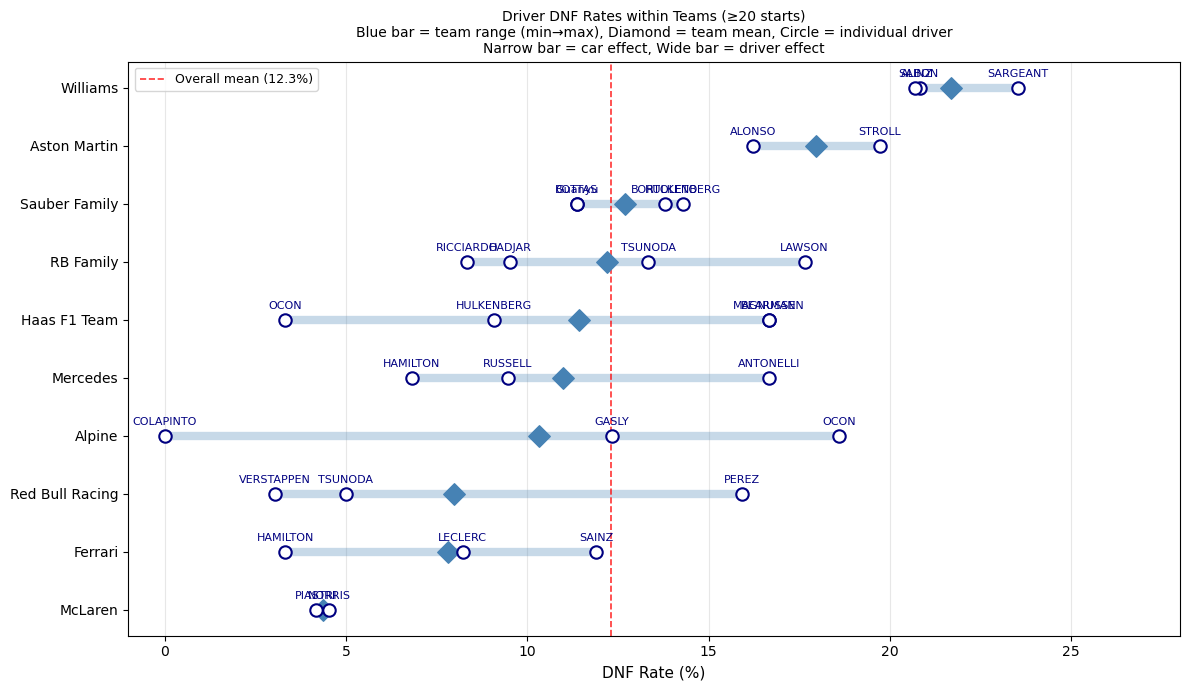

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# recompute with >=20 starts threshold
driver_rates_20 = driver_rates[driver_rates['starts'] >= 20].copy()

team_summary_20 = driver_rates_20.groupby('team_name').agg(
    mean_dnf_rate=('dnf_rate','mean'),
    min_dnf_rate=('dnf_rate','min'),
    max_dnf_rate=('dnf_rate','max')
).reset_index()
team_summary_20['rate_spread'] = team_summary_20['max_dnf_rate'] - team_summary_20['min_dnf_rate']
teams_sorted_20 = team_summary_20.sort_values('mean_dnf_rate', ascending=True)['team_name'].tolist()

fig, ax = plt.subplots(figsize=(12, 7))

for i, team in enumerate(teams_sorted_20):
    team_drivers = driver_rates_20[driver_rates_20['team_name'] == team]
    team_meta = team_summary_20[team_summary_20['team_name'] == team].iloc[0]
    
    # draw range bar (min to max)
    ax.hlines(i, team_meta['min_dnf_rate']*100, team_meta['max_dnf_rate']*100,
              linewidth=6, color='steelblue', alpha=0.3, zorder=2)
    
    # draw team mean
    ax.scatter(team_meta['mean_dnf_rate']*100, i,
               color='steelblue', s=120, zorder=4, marker='D')
    
    # draw individual drivers
    for _, driver in team_drivers.iterrows():
        ax.scatter(driver['dnf_rate']*100, i,
                   color='white', s=80, zorder=5,
                   edgecolors='navy', linewidth=1.5)
        # last name only, offset above
        last_name = driver['full_name'].split()[-1]
        ax.annotate(last_name,
                    (driver['dnf_rate']*100, i),
                    textcoords='offset points',
                    xytext=(0, 8),
                    fontsize=8, ha='center', color='navy')

# overall mean line
ax.axvline(x=12.3, color='red', linestyle='--', 
           linewidth=1.2, label='Overall mean (12.3%)', alpha=0.8)

ax.set_yticks(range(len(teams_sorted_20)))
ax.set_yticklabels(teams_sorted_20, fontsize=10)
ax.set_xlabel('DNF Rate (%)', fontsize=11)
ax.set_title('Driver DNF Rates within Teams (≥20 starts)\n'
             'Blue bar = team range (min→max), Diamond = team mean, '
             'Circle = individual driver\n'
             'Narrow bar = car effect, Wide bar = driver effect',
             fontsize=10)
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(-1, 28)
plt.tight_layout()
plt.show()

STATISTICAL POWER CAVEAT -- UPFRONT:

Minimum starts threshold: ≥20 starts (raised from initial ≥15 suggestion 
after power calculation). Not a statistically powered threshold -- a 
credibility floor to exclude drivers whose DNF rate is dominated by single 
events. Any driver with <20 starts was excluded from the comparison.

METHOD:
Computed per-driver DNF rate (dnfs/starts) for all drivers with ≥20 race 
starts, dns=0, Cadillac excluded. Then computed within-team spread 
(max_dnf_rate - min_dnf_rate) as the key diagnostic: narrow spread = 
drivers similar = car effect, wide spread = drivers differ = driver/
circumstantial effect.

WITHIN-TEAM SPREAD RESULTS:

NARROW SPREAD (car effect -- drivers similar):
  McLaren:      spread=0.004 (Norris ~4.2%, Piastri ~4.5%) -- tightest 
                cluster of all teams. Both drivers far left of the mean. 
                Reliably reliable car regardless of who drives it.
  Williams:     spread=0.028 (Albon 20.8%, Sainz 20.7%, Sargeant 23.5%)
                -- three DIFFERENT drivers, all clustered at 20-23% DNF 
                rate. Strongest car-effect signal in the dataset.
  Sauber:       spread=0.029 -- four drivers all near the overall mean.
  Aston Martin: spread=0.035 (Alonso 16.2%, Stroll 19.7%) -- both above 
                average, car effect.

WIDE SPREAD (driver/circumstantial effect -- drivers differ):
  Alpine:       spread=0.186 -- largest spread. Colapinto ~2% vs Ocon 
                ~18.6%. Massive within-team divergence.
  Red Bull:     spread=0.129 -- Verstappen/Tsunoda ~3-5% vs Perez ~15.9%.
  Haas:         spread=0.133 -- Ocon ~3% vs Magnussen/Bearman ~16.7%.
  Mercedes:     spread=0.099 -- Hamilton ~6.8%, Russell ~10%, 
                Antonelli ~16.7%.

NATURAL EXPERIMENT -- CARLOS SAINZ:
The most compelling single piece of evidence for car vs driver effect:
  Sainz at Ferrari (42 starts): DNF rate = 11.9% (near overall mean)
  Sainz at Williams (29 starts): DNF rate = 20.7% (matches Williams average)

Same driver, different car, different DNF rate. His Williams rate matches 
his Williams teammates' rates exactly. His Ferrari rate matches Ferrari's 
team rate. This directly confirms the car effect at Williams -- the 
fragility follows the car, not the driver.

NUANCE ON "WIDE SPREAD = DRIVER EFFECT":
Wide within-team spread doesn't automatically mean skill-based driver 
differences. Three alternative explanations:

1. EXPERIENCE/ROOKIE EFFECT: Mercedes spread (Hamilton 6.8% → Antonelli 
   16.7%) most likely reflects rookie vs veteran difference. Antonelli 
   replaced Hamilton in 2026 with ~30 starts total. Rookie drivers push 
   harder at the limit, make more errors under pressure, and are less 
   experienced at managing a car showing early mechanical symptoms. 
   Expected to narrow as Antonelli gains experience.

2. CIRCUMSTANTIAL PRESSURE: Perez's elevated rate at Red Bull (15.9% vs 
   Verstappen ~3%) coincided with his difficult 2024 season under intense 
   contract/performance pressure -- pushing beyond comfortable limits.

3. MID-SEASON TEAM CHANGES: Some "drivers" in wide-spread teams represent 
   partial seasons or stand-in appearances, making their rates less 
   representative.

DNF rate alone cannot distinguish these explanations -- you'd need 
retirement cause, lap of retirement, and whether it was avoidable to 
separate genuine fragility from circumstantial factors.

TAKEAWAY:
Two types of teams emerge from the within-team spread analysis:

CAR-EFFECT TEAMS (narrow spread, drivers similar):
  Williams and McLaren are the clearest examples -- opposite ends of the 
  reliability spectrum, but both show tight driver clustering. Williams 
  drivers consistently DNF at 20-23% regardless of who's driving; McLaren 
  drivers consistently finish at ~4-5%. Three different Williams drivers 
  across multiple seasons plus the Sainz natural experiment make the car-
  effect case compelling.

MIXED/DRIVER-EFFECT TEAMS (wide spread, drivers differ):
  Alpine, Red Bull, Haas, and Mercedes show meaningful within-team 
  divergence. But "driver effect" here is probably better described as 
  "circumstantial effects" -- rookie status, contract pressure, team 
  transitions -- rather than pure skill differences in car management.

STATISTICAL REMINDER:
None of the driver-level comparisons in this question are statistically 
confirmed (would need ~233 starts per driver). The descriptive patterns 
are suggestive and internally consistent, but should be treated as 
hypothesis-generating rather than hypothesis-confirming.

CONVERGES WITH PREVIOUS QUESTION:
The team-level DNF analysis (p=0.001) identified Williams and Aston Martin 
as the most fragile teams, McLaren and Ferrari as the most reliable. The 
within-team spread analysis confirms and extends this: Williams' fragility 
is a car effect (tight driver clustering at high DNF rates), McLaren's 
reliability is a car effect (tight driver clustering at low DNF rates). 
The Sainz natural experiment provides the cleanest single-driver 
confirmation of the car effect.

- [X] Does rain increase the *variance* of finishing positions across the field, not just average pace? (compare position variance in wet vs. dry races F-test / Levene's test)

In [19]:
variance_query = """
SELECT sr.session_key, sr.driver_number,
       sr.position AS finish_position,
       MAX(w.rainfall) AS race_had_rain,
       m.circuit_short_name
FROM silver_session_result sr
JOIN silver_sessions s ON sr.session_key = s.session_key 
    AND s.session_name = 'Race'
JOIN silver_meetings m ON s.meeting_key = m.meeting_key
LEFT JOIN silver_weather w ON sr.session_key = w.session_key
WHERE sr.dnf = 0 AND sr.dns = 0 AND sr.dsq = 0
  AND sr.position IS NOT NULL
GROUP BY sr.session_key, sr.driver_number, 
         sr.position, m.circuit_short_name
"""
df_var = pd.read_sql(variance_query, conn)


In [20]:

# merge grid position
grid_query = """
SELECT g.driver_number, g.position AS grid_position, gs.meeting_key,
       (SELECT rs.session_key FROM silver_sessions rs 
        WHERE rs.meeting_key = gs.meeting_key 
        AND rs.session_name = 'Race' LIMIT 1) AS session_key
FROM silver_starting_grid g
JOIN silver_sessions gs ON g.session_key = gs.session_key
WHERE gs.session_name = 'Qualifying'
"""
df_grid = pd.read_sql(grid_query, conn)


In [21]:

df_var = df_var.merge(df_grid[['session_key','driver_number','grid_position']],
                       on=['session_key','driver_number'], how='left')
df_var = df_var.dropna(subset=['grid_position','race_had_rain']).copy()
df_var['position_change'] = df_var['grid_position'] - df_var['finish_position']

print(df_var.shape)
print(df_var['race_had_rain'].value_counts())
print(df_var['position_change'].describe())

(1121, 7)
race_had_rain
0.0    860
1.0    261
Name: count, dtype: int64
count    1121.000000
mean        0.983051
std         3.763153
min       -18.000000
25%        -1.000000
50%         1.000000
75%         3.000000
max        16.000000
Name: position_change, dtype: float64


In [22]:
from scipy.stats import levene, bartlett

# compute variance of position_change within each race
race_variance = df_var.groupby(['session_key','race_had_rain'])['position_change'].var().reset_index()
race_variance.columns = ['session_key','race_had_rain','position_change_variance']

print(race_variance.shape)
print(race_variance.groupby('race_had_rain')['position_change_variance'].describe())

# split into wet and dry
dry_var = race_variance[race_variance['race_had_rain']==0]['position_change_variance']
wet_var = race_variance[race_variance['race_had_rain']==1]['position_change_variance']

print(f"\nDry races: n={len(dry_var)}, mean variance={dry_var.mean():.3f}, median={dry_var.median():.3f}")
print(f"Wet races: n={len(wet_var)}, mean variance={wet_var.mean():.3f}, median={wet_var.median():.3f}")

# Levene's test -- robust to non-normality, preferred for this kind of comparison
stat, p_levene = levene(dry_var, wet_var)
print(f"\nLevene's test: stat={stat:.3f}, p={p_levene:.6f}")

# F-test (Bartlett) -- more powerful but assumes normality
stat_b, p_bartlett = bartlett(dry_var, wet_var)
print(f"Bartlett's test: stat={stat_b:.3f}, p={p_bartlett:.6f}")

(65, 3)
               count       mean        std       min       25%        50%  \
race_had_rain                                                               
0.0             50.0  13.848637   9.483909  1.733333  7.835784  11.971726   
1.0             15.0  16.745682  11.117242  3.684211  8.562377  14.912281   

                     75%        max  
race_had_rain                        
0.0            19.150770  53.889706  
1.0            22.473684  40.409524  

Dry races: n=50, mean variance=13.849, median=11.972
Wet races: n=15, mean variance=16.746, median=14.912

Levene's test: stat=0.790, p=0.377517
Bartlett's test: stat=0.568, p=0.451249


PRE-ANALYSIS INTUITION (confirmed):
Based on the earlier DNF analysis finding that rain doesn't significantly 
increase DNF rate (dry 12.5% vs wet 11.4%, p=0.672), we anticipated that 
rain was unlikely to dramatically increase finishing position variance 
either. DNFs are one of the biggest drivers of unusual position reshuffling, 
so if rain doesn't cause more retirements, its effect on overall variance 
was expected to be modest. This intuition was confirmed.

METHOD:
Outcome: per-race variance of position_change (grid_position - 
finish_position) across all classified finishers (dnf=0, dns=0, dsq=0, 
position not null). Using position_change rather than raw finishing 
position captures "how much did the race reshuffle the order relative to 
qualifying?" -- a more meaningful measure of race chaos than raw finishing 
position variance (which is structurally fixed at 1-20 in a full field).

Population: 1,121 driver-race rows → 65 race-level variance observations 
(50 dry, 15 wet). Rainfall defined as MAX(silver_weather.rainfall) per 
session -- binary flag for any rain during the race.

Two tests of variance equality:
  Levene's test -- robust to non-normality, preferred for this comparison
  Bartlett's test -- more powerful but assumes normality of variance 
  distributions

RESULTS:
  Dry races  (n=50): mean variance=13.849, median variance=11.972
  Wet races  (n=15): mean variance=16.746, median variance=14.912

  Levene's test:   stat=0.790, p=0.378 -- NOT significant
  Bartlett's test: stat=0.568, p=0.451 -- NOT significant

Both tests agree -- no ambiguity between them. The direction is correct 
(wet races do show slightly higher variance: +2.9 mean, +2.9 median) but 
the difference is not statistically detectable.

INTERPRETATION:
Rain does NOT significantly increase finishing position variance relative 
to grid position in this data. Wet races produce slightly more shuffling 
on average (+21% higher mean variance) but this difference is within 
normal race-to-race noise.

Several factors explain why rain's effect is smaller than intuition 
suggests:
  1. F1 has strong variance-dampening mechanisms in wet conditions: 
     Safety Cars, VSCs, and red flags all bunch the field and reduce the 
     magnitude of position swings. These mechanisms are deployed MORE 
     aggressively in wet conditions, partially offsetting rain's chaos.
  2. Modern F1 teams are very good at wet-weather strategy -- the field 
     tends to react similarly to rain (all pit for intermediates within 
     1-2 laps of each other), limiting strategic divergence.
  3. Dry races can also produce extreme variance through Safety Cars, 
     unusual strategy, and mechanical issues -- the max dry variance 
     (53.9) exceeded the max wet variance (40.4), showing dry races are 
     not inherently more predictable.

SAMPLE SIZE LIMITATION:
Only 15 wet races in the dataset (across 2023-2026) -- a small sample 
for a variance comparison. A few unusually chaotic wet races could inflate 
the wet mean without representing a systematic effect. The test is 
underpowered to detect modest variance differences at this sample size. 
A larger dataset spanning more seasons would be needed to confirm or 
reject the directional trend (wet → slightly higher variance) with 
statistical confidence.

TAKEAWAY:
Rain does not reliably increase finishing position variance beyond normal 
race-to-race variation. The directional trend exists (+21% higher mean 
variance in wet races) but is not statistically significant with 15 wet 
races available. Combined with the earlier finding that rain doesn't 
increase DNF rate, both analyses converge on the same story: F1's 
regulatory response to wet conditions (SC, VSC, red flags) effectively 
dampens the chaos that rain might otherwise introduce, making wet races 
less dramatically different from dry races than casual intuition suggests.

CONVERGES WITH PREVIOUS FINDING:
DNF analysis (p=0.672): rain not associated with higher DNF rate.
Variance analysis (p=0.378): rain not associated with higher position 
variance.
Both findings point at the same mechanism: F1's race management 
infrastructure (Safety Car, VSC, red flags) absorbs the chaos that rain 
introduces, producing outcomes more similar to dry races than expected.

- [X] Do specific teams or drivers statistically outperform their own dry-weather baseline in wet races? (paired comparison, same driver/team, wet vs. dry)

In [23]:
# quick check -- wet race counts per team
df_var['race_had_rain'] = df_var['race_had_rain'].astype(int)
df_var2 = df_var.merge(
    pd.read_sql("""
        SELECT sr.session_key, sr.driver_number, d.team_name
        FROM silver_session_result sr
        JOIN silver_sessions s ON sr.session_key = s.session_key 
            AND s.session_name = 'Race'
        JOIN silver_drivers d ON sr.session_key = d.session_key 
            AND sr.driver_number = d.driver_number
        WHERE sr.dnf = 0 AND sr.dns = 0 AND sr.dsq = 0
    """, conn),
    on=['session_key','driver_number'], how='left'
)
df_var2 = normalize_team_names(df_var2)

print("Wet race appearances per team:")
print(df_var2[df_var2['race_had_rain']==1].groupby('team_name')['session_key'].nunique().sort_values())
print("\nWet race appearances per driver (top 20):")
print(df_var2[df_var2['race_had_rain']==1].groupby('driver_number')['session_key'].nunique().sort_values(ascending=False).head(20))

Wet race appearances per team:
team_name
Cadillac            1
Williams           13
Ferrari            14
RB Family          14
Sauber Family      14
Alpine             15
Aston Martin       15
Haas F1 Team       15
McLaren            15
Mercedes           15
Red Bull Racing    15
Name: session_key, dtype: int64

Wet race appearances per driver (top 20):
driver_number
1     15
44    15
31    15
14    15
22    14
81    14
63    14
10    14
4     13
18    13
55    12
16    12
27    12
23    11
11     9
77     9
24     7
2      6
3      6
20     5
Name: session_key, dtype: int64


In [25]:
# team level
team_wet_dry = df_var2.groupby(['team_name','race_had_rain'])['position_change'].agg(['mean','std','count']).reset_index()
team_wet_dry = team_wet_dry[team_wet_dry['team_name'] != 'Cadillac'].copy()

# pivot to wide format for easier comparison
team_pivot = team_wet_dry.pivot(index='team_name', columns='race_had_rain', values='mean')
team_pivot.columns = ['dry_mean','wet_mean']
team_pivot['wet_advantage'] = team_pivot['dry_mean'] - team_pivot['wet_mean']
# positive = better in wet (gained more places), negative = worse in wet

print(team_pivot.sort_values('wet_advantage', ascending=False).round(3))

                 dry_mean  wet_mean  wet_advantage
team_name                                         
Ferrari             1.154    -0.208          1.362
RB Family           0.276    -0.640          0.916
Mercedes            0.860     0.000          0.860
McLaren             0.275    -0.464          0.739
Red Bull Racing     1.864     1.250          0.614
Williams            1.662     1.652          0.010
Aston Martin        0.896     0.929         -0.032
Haas F1 Team        1.011     1.458         -0.447
Sauber Family       1.314     2.542         -1.228
Alpine              0.686     2.370         -1.684


In [47]:
names_query = """
SELECT DISTINCT driver_number, full_name
FROM silver_drivers
WHERE full_name IS NOT NULL
"""
df_names = pd.read_sql(names_query, conn)

# clean rebuild
driver_wet_dry = df_var2.groupby(['driver_number','race_had_rain'])['position_change'].agg(['mean','count']).reset_index()
driver_wet_dry.columns = ['driver_number','race_had_rain','mean_pos_change','race_count']

# separate wet and dry
dry = driver_wet_dry[driver_wet_dry['race_had_rain']==0][['driver_number','mean_pos_change','race_count']].rename(
    columns={'mean_pos_change':'dry_mean','race_count':'dry_count'})
wet = driver_wet_dry[driver_wet_dry['race_had_rain']==1][['driver_number','mean_pos_change','race_count']].rename(
    columns={'mean_pos_change':'wet_mean','race_count':'wet_count'})

# merge dry and wet side by side
driver_pivot = dry.merge(wet, on='driver_number', how='inner')
driver_pivot = driver_pivot[driver_pivot['wet_count'] >= 8].copy()
driver_pivot['wet_advantage'] = driver_pivot['dry_mean'] - driver_pivot['wet_mean']


In [49]:
driver_pivot = driver_pivot.merge(df_names_clean, on='driver_number', how='left')
print(driver_pivot[['full_name','driver_number','dry_count','wet_count',
                     'dry_mean','wet_mean','wet_advantage']]
      .sort_values('wet_advantage', ascending=False).round(3).to_string())

          full_name  driver_number  dry_count  wet_count  dry_mean  wet_mean  wet_advantage
5   Charles LECLERC             16         45         12     1.200    -1.167          2.367
1      Lando NORRIS              4         42         13     0.405    -1.538          1.943
7      Yuki TSUNODA             22         37         14     0.432    -1.000          1.432
11   Lewis HAMILTON             44         45         15     2.444     1.467          0.978
13   George RUSSELL             63         44         14     0.136    -0.643          0.779
10     Esteban OCON             31         41         15     1.927     1.267          0.660
6      Lance STROLL             18         35         13     2.029     1.462          0.567
8   Alexander ALBON             23         38         11     1.553     1.364          0.189
12     Carlos SAINZ             55         40         12     0.775     0.667          0.108
3      Sergio PEREZ             11         27          9     3.556     3.667    

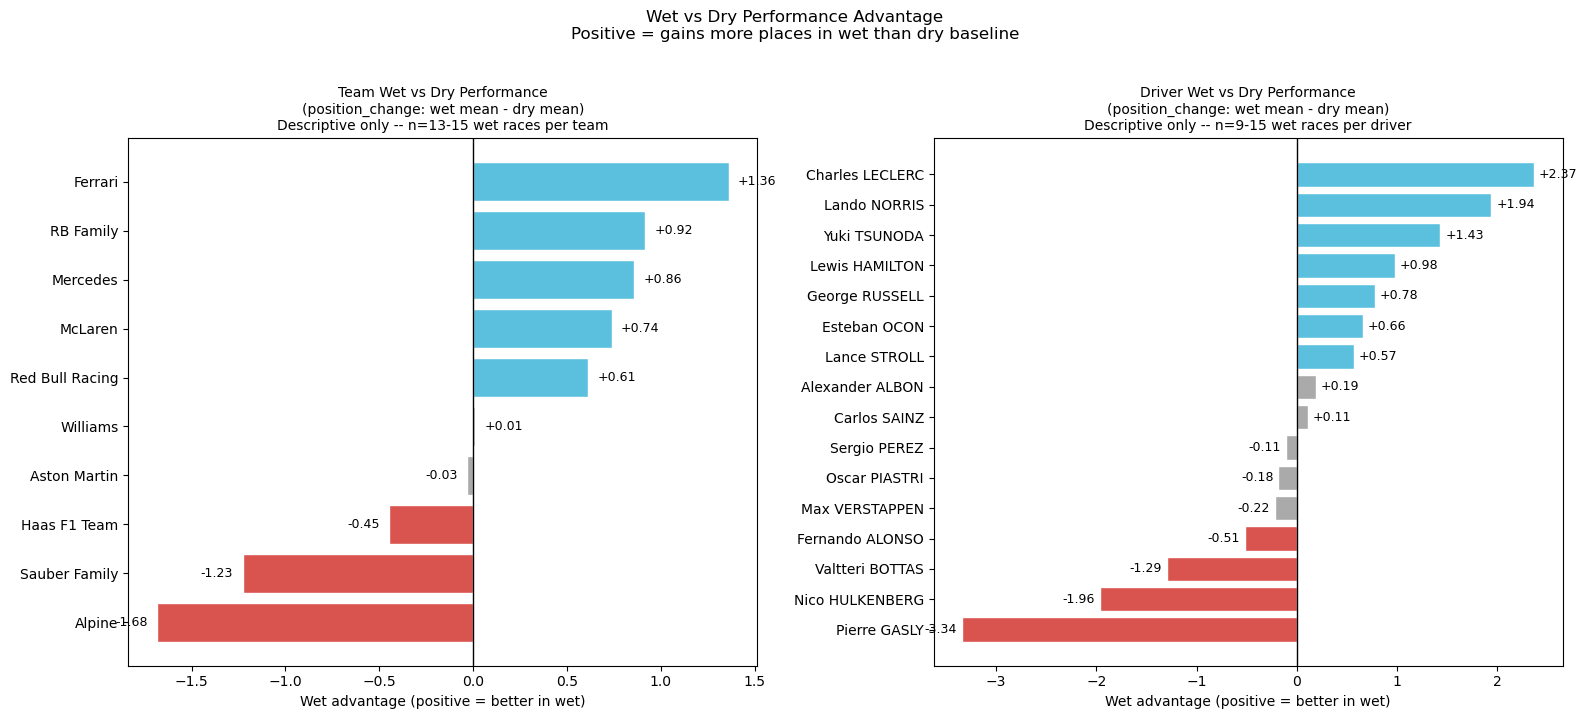

In [50]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Team plot
team_pivot_sorted = team_pivot.sort_values('wet_advantage', ascending=True)
colors_team = ['#d9534f' if x < -0.3 else '#5bc0de' if x > 0.3 else '#aaaaaa' 
               for x in team_pivot_sorted['wet_advantage']]
bars = axes[0].barh(team_pivot_sorted.index, team_pivot_sorted['wet_advantage'],
                    color=colors_team, edgecolor='white')
axes[0].axvline(x=0, color='black', linewidth=1)
axes[0].set_xlabel('Wet advantage (positive = better in wet)')
axes[0].set_title('Team Wet vs Dry Performance\n(position_change: wet mean - dry mean)\nDescriptive only -- n=13-15 wet races per team', fontsize=10)
for bar, val in zip(bars, team_pivot_sorted['wet_advantage']):
    axes[0].text(val + (0.05 if val >= 0 else -0.05), bar.get_y() + bar.get_height()/2,
                f'{val:+.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

# Driver plot
driver_pivot_sorted = driver_pivot.sort_values('wet_advantage', ascending=True)
colors_driver = ['#d9534f' if x < -0.5 else '#5bc0de' if x > 0.5 else '#aaaaaa' 
                 for x in driver_pivot_sorted['wet_advantage']]
bars2 = axes[1].barh(driver_pivot_sorted['full_name'], 
                     driver_pivot_sorted['wet_advantage'],
                     color=colors_driver, edgecolor='white')
axes[1].axvline(x=0, color='black', linewidth=1)
axes[1].set_xlabel('Wet advantage (positive = better in wet)')
axes[1].set_title('Driver Wet vs Dry Performance\n(position_change: wet mean - dry mean)\nDescriptive only -- n=9-15 wet races per driver', fontsize=10)
for bar, val in zip(bars2, driver_pivot_sorted['wet_advantage']):
    axes[1].text(val + (0.05 if val >= 0 else -0.05), bar.get_y() + bar.get_height()/2,
                f'{val:+.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.suptitle('Wet vs Dry Performance Advantage\nPositive = gains more places in wet than dry baseline', 
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


METHOD:
mean position_change (grid_position - finish_position) computed 
separately for wet and dry races per entity. Position_change chosen over 
raw finishing position to control for qualifying performance differences 
between wet and dry conditions.

wet_advantage = dry_mean_position_change - wet_mean_position_change
  Positive = entity gains MORE places in wet than in dry (wet specialist)
  Negative = entity gains FEWER places in wet than in dry (wet struggler)

Rainfall = MAX(silver_weather.rainfall) per session -- binary wet/dry flag.
Team level: all teams with ≥13 wet race appearances (Cadillac excluded).
Driver level: drivers with ≥8 wet race appearances (16 drivers qualify).
Minimum threshold of 8 starts is a credibility floor, not a powered 
threshold -- derived pragmatically given maximum of 15 wet races available.

TEAM RESULTS (descriptive):
Pattern: top-5 teams by car quality are ALL wet specialists; bottom-5 
are all wet strugglers. Suggests wet-weather performance tracks car 
quality closely -- better cars tend to also be better wet-weather cars.

DRIVER RESULTS (descriptive):

1. LECLERC VS SAINZ (same car, different wet performance):
   Leclerc: +2.37 wet advantage
   Sainz:   +0.11 wet advantage (essentially neutral)
   Both drove Ferrari for overlapping periods. This is a within-car 
   driver effect -- Leclerc appears to extract significantly more from 
   the car in wet conditions than Sainz did. Strongest driver-level wet 
   specialist signal in the dataset.

2. VERSTAPPEN ESSENTIALLY NEUTRAL (-0.22):
   Often described as a wet-weather specialist in F1 media. Data shows 
   him as essentially neutral -- likely because his dry performance is 
   already so strong (+0.71 places gained) that there is little room for 
   further improvement in wet conditions. His "wet specialist" reputation 
   may reflect absolute pace rather than relative wet vs dry advantage.

3. GASLY AS BIGGEST WET STRUGGLER (-3.34):
   Loses 3.57 places on average in wet races vs gaining 0.23 in dry. 
   Striking outlier -- though with only 14 wet races, a few particularly 
   bad wet races could be driving this average. Treat with caution.

4. TSUNODA SURPRISE (+1.43):
   Third strongest wet specialist despite driving for RB Family (midfield 
   car). Suggests genuine driver-level wet skill rather than car effect.

TEAM VS DRIVER PATTERN:
At team level, wet performance tracks car quality closely (top teams = 
wet specialists). At driver level, the pattern is more mixed -- some 
midfield drivers (Tsunoda, Ocon) show strong wet advantages while some 
top-team drivers (Verstappen, Piastri) are neutral. This suggests both 
car quality AND driver-specific wet skill contribute to wet-weather 
performance, but they're not perfectly correlated.
